### **Dataset**
**Glass Identification (UCI / Kaggle)**  
Each row = one glass sample  
Each column = one measurement  
One column = the class/type of glass


## **1. Setup (Imports)**

We will use:
- **NumPy** for vector math  
- **Pandas** for loading and inspecting data  
- **Scikit-learn** only for train/test split and feature scaling  

> Important: The **logistic regression model itself is implemented from scratch** using NumPy.


In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

## **2. Load the Dataset**

### What we want
A table of numbers:
- Rows = samples  
- Columns = features + label  

### Important note (Colab)
If you're using Google Colab, you can:
- Upload `glass.csv` manually, OR  
- Mount Google Drive, OR  
- Download from Kaggle (requires Kaggle API setup)

For this lab, we assume `glass.csv` is available in the working directory.


In [ ]:
# TODO: load the glass dataset into df
df = pd.read_csv("/content/glass.csv")
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


## **3.** **Look at the Data (Very Important)**

Before modeling, we must understand what we are working with.

We will check:
- shape (rows, columns)
- column names
- whether columns are numeric
- whether there is an ID column that should not be used

### Why this matters
Models do not understand meaning.  
They only see numbers.

If you include the wrong columns, the model learns the wrong thing.


In [ ]:
# TODO: check number of rows and columns
print("Shape (rows, cols):", df.shape)
print("\nColumns:")
print(df.columns)
df.head()

Shape (rows, cols): (214, 10)

Columns:
Index(['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type'], dtype='object')


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


### **Questions to be answered**

**Q1. Which column is the output we want to predict?**  
The output label column is **`Type`** (glass type/class).

**Q2. Are all columns numeric?**  
Yes, in the Glass dataset, all columns are numeric.

**Q3. Is there an ID column that should not be used?**  
Yes, usually the dataset contains an `Id` column (sample identifier).  
This column should not be used for learning because it carries no physical meaning and can mislead the model.

In the next cell, we will remove `Id` if it exists.


In [ ]:
# If an 'Id' column exists, drop it (it is not a meaningful feature)
if "Id" in df.columns:
    df = df.drop(columns=["Id"])
    print("Dropped 'Id' column.")
else:
    print("No 'Id' column found.")

No 'Id' column found.


## **4. Define the Learning Task (Binary Classification)**

The dataset contains multiple glass types.

For this lab, we convert it into a **binary classification** problem:

- **Type 1 → Positive class (1)**  
- **All other types → Negative class (0)**  

This is a **design choice**, not a rule.

### Why do we do this?
Because we are implementing **binary logistic regression** from scratch.


In [ ]:
# TODO: create binary labels
df["y"] = (df["Type"] == 1).astype(int)

# TODO: remove original Type column
df = df.drop(columns=["Type"])

df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,y
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


## **5. Separate Inputs (X) and Output (y)**

Models need:
- **X** → input features  
- **y** → labels  

Meaning:
- `X[i]` = measurements of sample `i`
- `y[i]` = correct answer for sample `i`


In [ ]:
# TODO: separate features and labels
X = df.drop(columns=["y"]).values
y = df["y"].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (214, 9)
y shape: (214,)


## **6. Train/Test Split**

We must evaluate on **unseen data**.

- Training set → model learns weights  
- Test set → model is evaluated fairly  

### Why this matters
Testing on training data gives **false confidence**.


In [ ]:
# TODO: split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 171
Test size: 43


## **7. Scale the Inputs (Standardization)**

Glass features have very different numeric ranges.

If we do not scale:
- sigmoid can saturate
- gradients become unstable
- learning becomes slow or fails

### StandardScaler does:
For each feature:
- subtract mean  
- divide by standard deviation  


In [ ]:
# TODO: scale features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaled training data mean (approx):", np.mean(X_train, axis=0)[:5])
print("Scaled training data std  (approx):", np.std(X_train, axis=0)[:5])

Scaled training data mean (approx): [ 7.91346358e-14 -1.15177523e-15  1.18651028e-16 -2.83074409e-16
 -2.27939824e-14]
Scaled training data std  (approx): [1. 1. 1. 1. 1.]


## **8. The Model We Are Implementing (Logistic Regression)**

Logistic regression computes:

### Step 1: Evidence score (linear)
\[
z = Xw + b
\]

### Step 2: Convert to probability (sigmoid)
\[
p = \sigma(z) = \frac{1}{1 + e^{-z}}
\]

Where:
- `w` = weights (importance of each feature)
- `b` = bias (default tendency)
- `p` = probability of class 1


## **9. Writing the Core Functions (Guided)**

We will implement:
1. Sigmoid  
2. Forward pass (predict probability)  
3. Binary cross entropy loss  
4. Gradient update  


In [ ]:
def sigmoid(z):
    """Convert a real-valued score into a probability in (0, 1)."""
    return 1 / (1 + np.exp(-z))

In [ ]:
def predict_proba(X, w, b):
    """Compute probabilities p(y=1|x) for each sample."""
    z = X @ w + b
    p = sigmoid(z)
    return p

### Why sigmoid matters
A step function throws away information (only YES/NO).  
Sigmoid preserves *how close* we are to the decision boundary.


In [ ]:
def loss(y, p, eps=1e-9):
    """Binary cross entropy loss."""
    # eps prevents log(0)
    p = np.clip(p, eps, 1 - eps)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

## **10. Learning Step (Single Update)**

Gradient descent updates only:
- weights `w`
- bias `b`

Key idea:
- `(p - y)` tells the direction and strength of correction.


In [ ]:
def update_weights(X, y, w, b, lr):
    """One gradient descent step."""
    p = predict_proba(X, w, b)
    error = p - y

    # Gradient for weights and bias
    dw = (X.T @ error) / len(y)
    db = np.mean(error)

    # Update
    w = w - lr * dw
    b = b - lr * db

    return w, b

## **11. Training Loop**

We will:
- initialize weights and bias
- run multiple epochs
- track loss over time

What should happen:
- loss decreases
- probabilities become more meaningful


In [ ]:
# TODO: initialize weights and bias
w = np.zeros(X_train.shape[1])
b = 0.0

lr = 0.1
epochs = 200

loss_history = []

for epoch in range(epochs):
    # Update parameters
    w, b = update_weights(X_train, y_train, w, b, lr)

    # Track loss
    p_train = predict_proba(X_train, w, b)
    current_loss = loss(y_train, p_train)
    loss_history.append(current_loss)

# Print final training loss
print("Final training loss:", loss_history[-1])

Final training loss: 0.4760006102261012


### Plot training loss

Loss should generally decrease over epochs.  
Small fluctuations are normal.


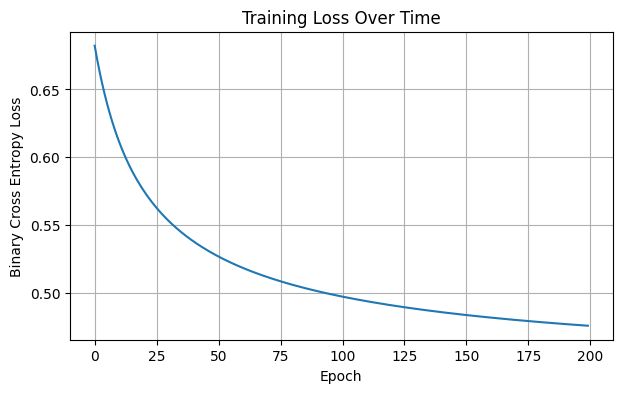

In [ ]:
plt.figure(figsize=(7,4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Binary Cross Entropy Loss")
plt.title("Training Loss Over Time")
plt.grid(True)
plt.show()

## **12. From Probability to Decision (Thresholding)**

The model outputs probabilities.

A hard decision is made by a **policy**:

- If `p >= threshold` → predict 1  
- else → predict 0  

We will test:
- threshold = 0.5  
- threshold = 0.7  

### Why try a higher threshold?
In quality control, false positives can be expensive.  
A higher threshold makes the model more conservative.


In [ ]:
def predict_label(p, threshold=0.5):
    return (p >= threshold).astype(int)

**13. Evaluation on Test Set**

We will compute:
- Accuracy  
- Confusion Matrix (manual)
- Precision, Recall (manual)

We compute these ourselves to strengthen understanding.


In [ ]:
def confusion_matrix_manual(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return tp, tn, fp, fn

def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

def precision(tp, fp, eps=1e-9):
    return tp / (tp + fp + eps)

def recall(tp, fn, eps=1e-9):
    return tp / (tp + fn + eps)

In [ ]:
# Predict probabilities on test set
p_test = predict_proba(X_test, w, b)

# Evaluate with threshold 0.5
y_pred_05 = predict_label(p_test, threshold=0.5)
tp, tn, fp, fn = confusion_matrix_manual(y_test, y_pred_05)

print("=== Threshold = 0.5 ===")
print("Accuracy :", accuracy(y_test, y_pred_05))
print("TP, TN, FP, FN:", tp, tn, fp, fn)
print("Precision:", precision(tp, fp))
print("Recall   :", recall(tp, fn))

=== Threshold = 0.5 ===
Accuracy : 0.8372093023255814
TP, TN, FP, FN: 7 29 3 4
Precision: 0.69999999993
Recall   : 0.6363636363057851


In [ ]:
# Evaluate with threshold 0.7
y_pred_07 = predict_label(p_test, threshold=0.7)
tp, tn, fp, fn = confusion_matrix_manual(y_test, y_pred_07)

print("=== Threshold = 0.7 ===")
print("Accuracy :", accuracy(y_test, y_pred_07))
print("TP, TN, FP, FN:", tp, tn, fp, fn)
print("Precision:", precision(tp, fp))
print("Recall   :", recall(tp, fn))

=== Threshold = 0.7 ===
Accuracy : 0.7209302325581395
TP, TN, FP, FN: 0 31 1 11
Precision: 0.0
Recall   : 0.0


## **14.** **Understanding the Difference vs Perceptron (Final Answer Paragraph)**

### How this differs from perceptron?
A perceptron outputs only a hard class label (0/1).  
Logistic regression outputs a probability using the sigmoid function.

### Why sigmoid matters?
Sigmoid converts the linear score into a smooth probability in (0,1).  
This keeps information about uncertainty and gives a meaningful confidence value.

### What problem still remains unsolved?
Even with probabilities, logistic regression is still a **linear model**.  
If the data is not linearly separable in the feature space, performance will be limited.  
More complex models (feature engineering, kernels, neural networks) are needed for non-linear boundaries.
